# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

In [66]:
#We have a supervised learning problem, or more specific, a regression task. The target we want to predict is the car price (y), which is a continuous number.
#We will use the dataset of 426K cars to train a machine learning model, for example, a Linear Regression or a Decision Tree.
#The input features (X) will be the car details.
#After we clean the data and train the model, we will look at the feature importance or the model coefficients.
#This will show us exactly which factors have the biggest impact on the price, so we can give clear advice to the dealership.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [68]:
# 1. Load the dataset
df = pd.read_csv('vehicles.csv')

In [69]:

# Check the size of the dataset
print(f"Dataset Shape: {df.shape}\n")

# View the columns and their data types
print("Data Types and Non-Null Counts:")
print(df.info())
print("\nFirst 5 rows of the data:")
print(df.head())

Dataset Shape: (426880, 18)

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  

In [70]:
# Summary statistics for numerical columns
print("Summary of Numerical Columns:")
print(df.describe())

# Summary for categorical columns (text data)
print("\nSummary of Categorical Columns:")
print(df.describe(include=['object']))

Summary of Numerical Columns:
                 id         price           year      odometer
count  4.268800e+05  4.268800e+05  425675.000000  4.224800e+05
mean   7.311487e+09  7.519903e+04    2011.235191  9.804333e+04
std    4.473170e+06  1.218228e+07       9.452120  2.138815e+05
min    7.207408e+09  0.000000e+00    1900.000000  0.000000e+00
25%    7.308143e+09  5.900000e+03    2008.000000  3.770400e+04
50%    7.312621e+09  1.395000e+04    2013.000000  8.554800e+04
75%    7.315254e+09  2.648575e+04    2017.000000  1.335425e+05
max    7.317101e+09  3.736929e+09    2022.000000  1.000000e+07

Summary of Categorical Columns:
          region manufacturer   model condition    cylinders    fuel  \
count     426880       409234  421603    252776       249202  423867   
unique       404           42   29649         6            8       5   
top     columbus         ford   f-150      good  6 cylinders     gas   
freq        3608        70985    8009    121456        94169  356209   

       ti

In [71]:

# Count missing values
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Only show columns with missing data

# Check for duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Missing Values:
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
dtype: int64

Number of duplicate rows: 0


In [72]:
# Fill missing categorical data with 'unknown'
cat_cols = ['condition', 'fuel', 'transmission', 'title_status', 'drive', 'type']
for col in cat_cols:
    df[col] = df[col].fillna('unknown')

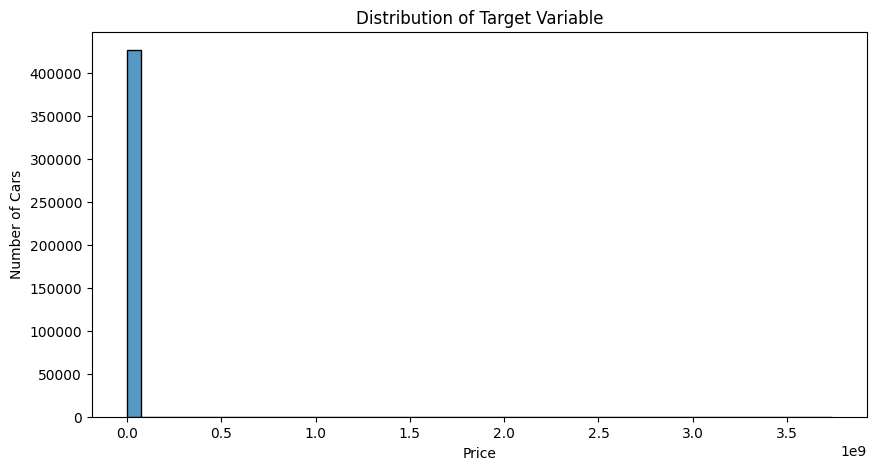

In [73]:
#Target distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50)
plt.title('Distribution of Target Variable')
plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.show()

In [74]:
#Outliers. Data quality problem.

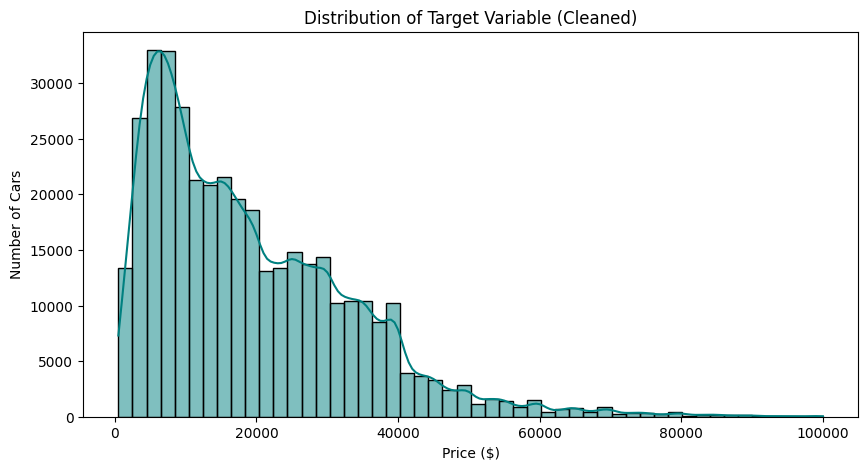

In [75]:
# Create a filtered version of your data just for the chart
# This removes $0 prices and the multi-million/billion dollar mistakes
df_filtered = df[(df['price'] > 500) & (df['price'] < 100000)]

# Plot again with the clean data
plt.figure(figsize=(10, 5))
sns.histplot(df_filtered['price'], bins=50, kde=True, color='teal')
plt.title('Distribution of Target Variable (Cleaned)')
plt.xlabel('Price ($)')
plt.ylabel('Number of Cars')
plt.show()

In [76]:
#The highier pick is between $5K and $10K. This means the biggest part of the market consists of affordable cars.

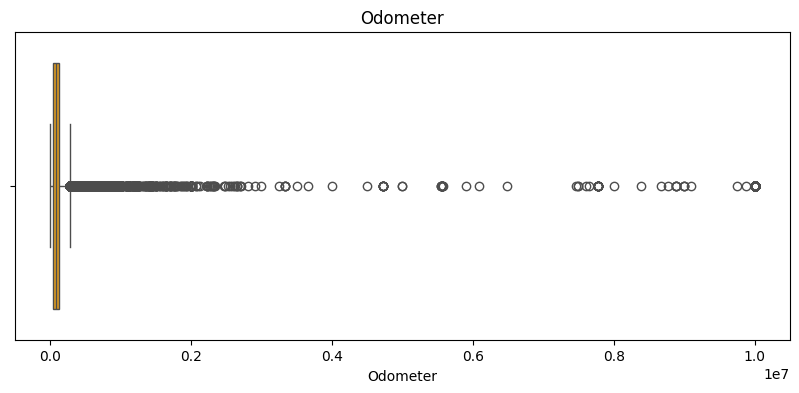

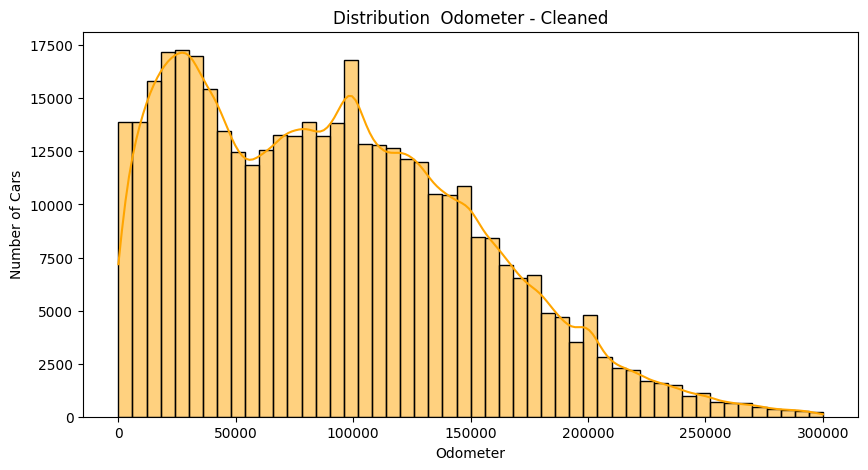

In [77]:
# Outilier?
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='odometer', color='orange')
plt.title('Odometer')
plt.xlabel('Odometer')
plt.show()

#Yes, we need to clean the DF.
#Clean the odometer. Filter cars with less than 100 miles or more than 300,000 miles.
df_clean_miles = df[(df['odometer'] > 100) & (df['odometer'] < 300000)]

# Clean odometer distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean_miles['odometer'], bins=50, kde=True, color='orange')
plt.title('Distribution  Odometer - Cleaned')
plt.xlabel('Odometer')
plt.ylabel('Number of Cars')
plt.show()

In [78]:
# Most of the cars have not more then 150 000 miles.

In [79]:
#We can see de depreciation of the vehicle over the time

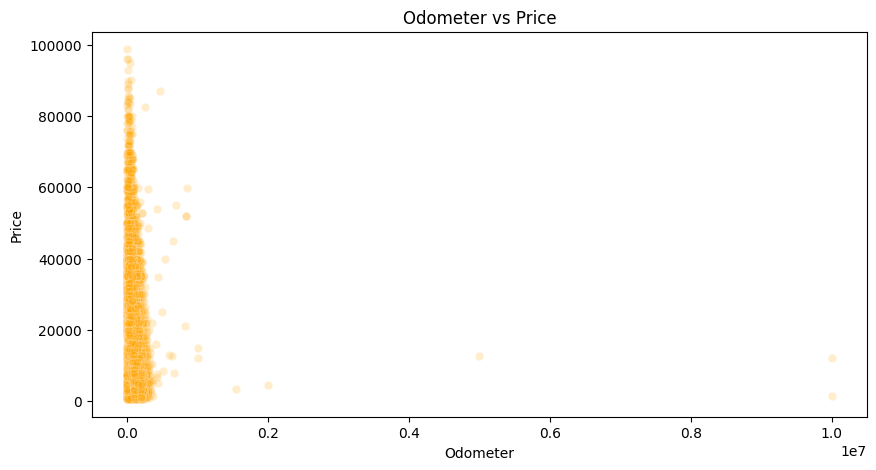

In [80]:
#MILEAGE vs target
df_clean = df[(df['price'] > 500) & (df['price'] < 100000)].copy()
plt.figure(figsize=(10, 5))
# We take a sample of 10,000 cars so the scatter plot doesn't freeze the screen
df_sample = df_clean.sample(10000, random_state=42)
sns.scatterplot(data=df_sample, x='odometer', y='price', alpha=0.2, color='orange')
plt.title('Odometer vs Price')
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.show()


In [81]:
#Data quality problem: few extreme outliers. We clean the data. ( we saw it also in the previous analysis)

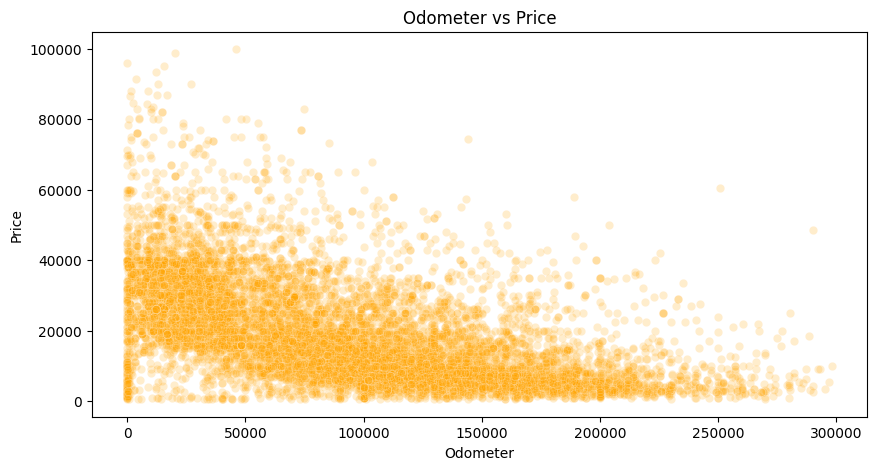

In [82]:
df_clean = df[(df['price'] > 500) & (df['price'] < 100000)].copy()
df_filtered_miles = df_clean[df_clean['odometer'] < 300000]
plt.figure(figsize=(10, 5))
# We take a sample of 10,000 cars so the scatter plot doesn't freeze the screen
df_sample = df_filtered_miles.sample(10000, random_state=42)
sns.scatterplot(data=df_sample, x='odometer', y='price', alpha=0.2, color='orange')
plt.title('Odometer vs Price')
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.show()

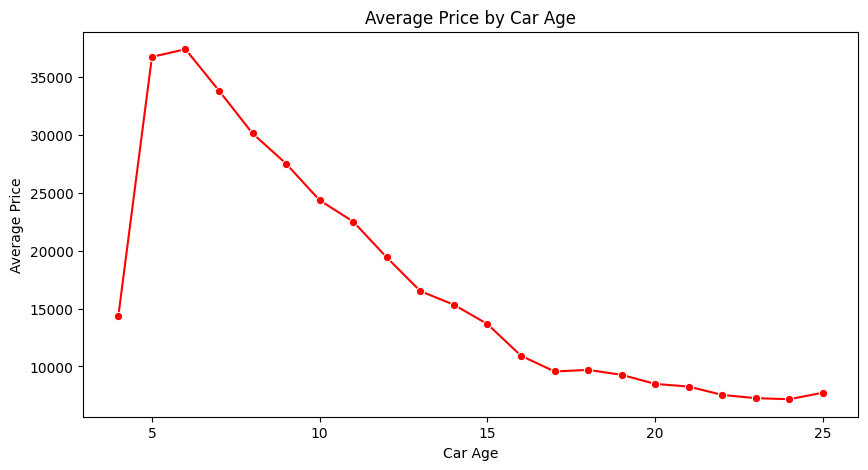

In [83]:
# AGE - Target relation
df_clean_age = df[(df['price'] > 500) & (df['price'] < 100000)].copy()
df_clean_age = df_clean_age.dropna(subset=['year'])

# Create the 'car_age' column
df_clean_age['car_age'] = 2026 - df_clean_age['year']
df['car_age'] = 2026 - df['year']
# Group by car age to see how average price drops over time
age_price = df_clean_age.groupby('car_age')['price'].mean().reset_index()

# Plot the graph
plt.figure(figsize=(10, 5))
sns.lineplot(data=age_price[age_price['car_age'] <= 25], x='car_age', y='price', marker='o', color='red')#looking for cars not older then 25 years
plt.title('Average Price by Car Age')
plt.xlabel('Car Age')
plt.ylabel('Average Price')
plt.show()


In [84]:
#We can observe a negative correlation. This visually proves that as mileage increases, the value of the car drops systematically.

/tmp/ipykernel_6286/1484314135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='condition', y='price', palette='muted', errorbar=None)


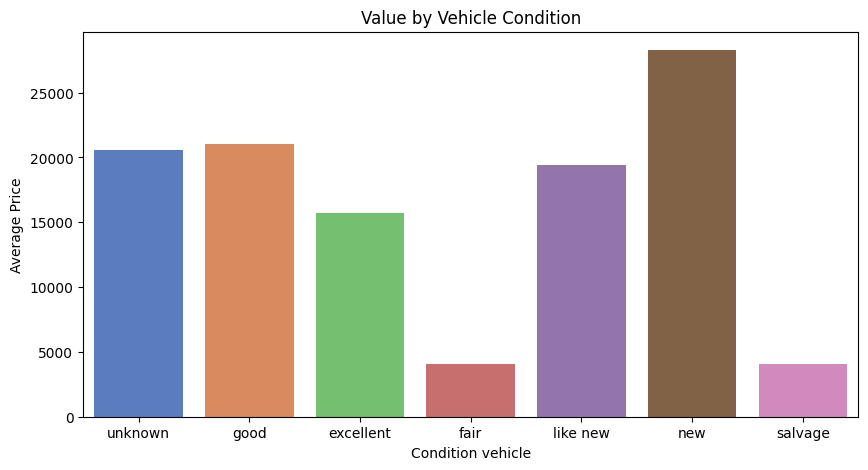

In [85]:
# Condition of the vehicle vs Price
plt.figure(figsize=(10, 5))
condition_order = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage', 'unknown']
sns.barplot(data=df_clean, x='condition', y='price', palette='muted', errorbar=None)
plt.title('Value by Vehicle Condition')
plt.xlabel('Condition vehicle')
plt.ylabel('Average Price')
plt.show()




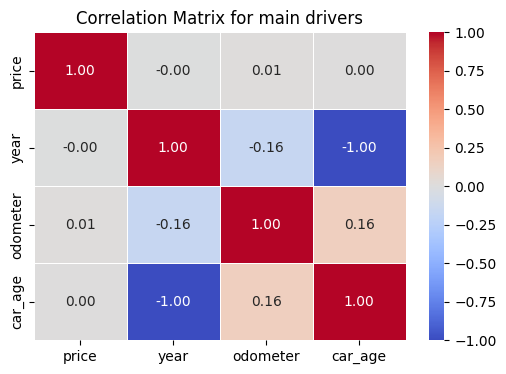

In [86]:
#CORRELATION MATRIX
plt.figure(figsize=(6, 4))
correlation = df[['price', 'year', 'odometer', 'car_age']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix for main drivers')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [87]:

df['year']

#Managing outliers, Cleaning for the variables price, odometer, year
df_prep = df[(df['price'] > 500) & (df['price'] < 100000)].copy()
df_prep = df_prep[(df_prep['odometer'] > 100) & (df_prep['odometer'] < 300000)]
df_prep = df_prep[(df_prep['year'] >= 1990) & (df_prep['year'] <= 2024)]



In [88]:
#Feature Engineering
#create some business important drivers in the price vehicle
df_prep['car_age'] = 2026 - df_prep['year']
df_prep['miles_per_year'] = df_prep['odometer'] / (df_prep['car_age'] + 1) # +1 prevents division by zero


In [89]:
# Create Target and Features
# We drop 'id', 'VIN', 'size' (too many missing), and 'model'/'region' too many unique words
drop_cols = ['id', 'price', 'VIN', 'size', 'year', 'model', 'region', 'state']
X = df_prep.drop(columns=drop_cols)
y = np.log1p(df_prep['price']) # Log transformation of target variable


In [90]:
# Group features by type
num_features = ['odometer', 'car_age', 'miles_per_year']
cat_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color']

In [91]:
# Create Preprocessing Transformers using Sklearn Pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Just in case any missing numbers remain
    ('scaler', StandardScaler())                  # Scale to mean=0, var=1
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')), # Fill NaN with 'unknown'
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Convert text to 0/1
])

# Combine everything into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)


In [92]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Preprocessing
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [93]:
# Linear regression
lr_model = LinearRegression()
#Fold Cross Validation on Training Data to test stability
lr_cv_scores = cross_val_score(lr_model, X_train_ready, y_train, cv=5, scoring='r2')
print(f"Linear Regression Mean Cross-Val R2: {lr_cv_scores.mean():.4f}")

# Fit on full training data
lr_model.fit(X_train_ready, y_train)



Linear Regression Mean Cross-Val R2: 0.6886


LinearRegression()

In [94]:

#RIDGE REGRESSION
#HYPERPARAMETER TUNING
ridge = Ridge()
# Test different alpha strengths (higher alpha = more regularization)
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}


# GridSearchCV handles cross-validation and parameter testing automatically
ridge_search = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_search.fit(X_train_ready, y_train)

best_ridge = ridge_search.best_estimator_
print(f"Best Ridge Alpha: {ridge_search.best_params_}")
print(f"Ridge Best Cross-Val R2: {ridge_search.best_score_:.4f}")



Best Ridge Alpha: {'alpha': 0.1}
Ridge Best Cross-Val R2: 0.6886


In [95]:

#LASSO REGRESSION
#HYPERPARAMETER TUNING

lasso = Lasso(max_iter=1000)
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1]}

lasso_search = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_search.fit(X_train_ready, y_train)

best_lasso = lasso_search.best_estimator_
print(f"Best Lasso Alpha: {lasso_search.best_params_}")
print(f"Lasso Best Cross-Val R2: {lasso_search.best_score_:.4f}")

Best Lasso Alpha: {'alpha': 0.0001}
Lasso Best Cross-Val R2: 0.6882


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [96]:

#R^2 score that is almost exactly the same (~0.6886)
#basic Linear Regression can be fragile, we select the Ridge as the R2 is slightly better then Lasso


In [97]:
# Choose Ridge as the final model. Best score
final_model = best_ridge

# Make final predictions on the Test Set
final_preds_log = final_model.predict(X_test_ready)

In [98]:
# Reverse the log transformation
# Because we used np.log1p() before, we use np.expm1() to get real prices.
final_preds_dollars = np.expm1(final_preds_log)
real_prices_dollars = np.expm1(y_test)

# Calculate the average mistake in real price
mae_dollars = mean_absolute_error(real_prices_dollars, final_preds_dollars)

print(f"Final Chosen Model: Ridge Regression (Alpha=0.1)")
print(f"On average, our model's price prediction is off by: ${mae_dollars:.2f}")

Final Chosen Model: Ridge Regression (Alpha=0.1)
On average, our model's price prediction is off by: $4926.48


In [99]:

# Model we choose
X_train_ready = preprocessor.fit_transform(X_train)
best_ridge.fit(X_train_ready, y_train)

# Get the feature names after they were transformed by One-Hot Encoding
all_features = list(preprocessor.get_feature_names_out())


In [100]:

#Features vs Ridge model coefficients
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': best_ridge.coef_
})

# Clean up the names
feature_importance['Feature'] = feature_importance['Feature'].str.replace('num__', '').str.replace('cat__', '')

# Sort by absolute value to find the strongest drivers
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

# Print the top 10 results for the dealership
print("TOP 10 DRIVERS OF USED CAR PRICES:")
print(feature_importance[['Feature', 'Coefficient']].head(10))

TOP 10 DRIVERS OF USED CAR PRICES:
                    Feature  Coefficient
32      manufacturer_morgan    -2.042427
13     manufacturer_ferrari     1.210565
70  title_status_parts only    -0.636109
35     manufacturer_porsche     0.627432
53   cylinders_12 cylinders     0.562785
61              fuel_diesel     0.549656
40       manufacturer_tesla     0.520273
50        condition_salvage    -0.516295
69     title_status_missing    -0.514557
46           condition_fair    -0.463646


In [101]:
#Luxury brands (like Ferrari and Porsche), fully electric vehicles (like Tesla), and Diesel engines command the highest price premiums.
#Missing title, a salvage label, or a "parts only" status drops the car's price by 50% to 63% automatically.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [102]:
#Objective: Identify the key drivers of used car prices to optimize inventory acquisition and maximize sales profit.

In [103]:
#After data quality analysis and cleaning toutliers, we built a highly reliable model that successfully explains 69% of all price variations in the used car market.

In [104]:
#The Top Price Drivers:
# - Diesel Fuel Premium
# -Engine Power
# -Electric Vehicles
# -Luxury Branding: Strong brand equity dramatically changes prices
#Major Value Destroyers:
# -Parts Only Status
# -Missing Titles/Salvage Labels
# -"Fair" Condition

In [105]:
#Based on our data science findings, we recommend:
#Target the Diesel Market
#create Penalties on Titles (If a title is missing or marked as salvage, the purchase offer must be cut)
